# Supplementary Notebook 16: Pre-Modification Day-to-Day Comparison of SWATH-MS InterLab Benchmark Data

- **License:** [Creative Commons Attribution-NonCommercial 4.0 International License](https://creativecommons.org/licenses/by-nc/4.0/)
- **Version:** 0.2
- **Edit Log:**
    - 2026-03-14: Initial version of the notebook
    - 2026-03-14: Updated header, metadata, and study summary
    - 2026-03-24: Added section-level interpretation and benchmark-design framing
    - 2026-03-24: Revised conclusion to connect the pre-modification benchmark to later in silico perturbation analyses

---

**Requirements:**  
- Raw SWATH-MS benchmark input: `Benchmark/data/input/site02_global_q_0.01_applied_to_local_global.txt`
- Benchmark generation script: `Benchmark/01-DataProcessing.R`
- Prior notebook: None

**Purpose:**  
This notebook characterizes the benchmark data **before** the in silico perturbations from `Benchmark/01-DataProcessing.R` are introduced. The goal is to quantify the amount of baseline acquisition-day structure already present in the SWATH-MS inter-laboratory HEK293 dataset so the downstream perturbation benchmark can be interpreted against a realistic technical background rather than an assumed clean baseline.

The analysis is organized around three questions: whether runs separate by day at the global level, how stable peptide intensities remain across days, and how often protein-level summaries show a measurable day effect. These results define the pre-modification background that later benchmark inputs inherit before synthetic signals are added.

### Outline

| Part | Question |
|------|----------|
| 1 | Global similarity: do the 21 runs separate by acquisition day? |
| 2 | Peptide-level variation: how reproducible are peptide intensities across days? |
| 3 | Protein-level day effects: how many proteins show a measurable day effect? |
| 4 | Benchmark interpretation: what does this baseline imply for the later in silico benchmark? |

In [ ]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore', category=FutureWarning)

def find_project_root(start_dir, marker='requirements.txt'):
    current = os.path.abspath(start_dir)
    while True:
        if os.path.isfile(os.path.join(current, marker)):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            raise RuntimeError(f'Cannot find project root from CWD={start_dir}')
        current = parent

NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

def project_relative_label(path, root=PROJECT_ROOT):
    rel_path = os.path.relpath(path, root)
    root_name = os.path.basename(root.rstrip(os.sep))
    return root_name if rel_path == '.' else os.path.join(root_name, rel_path)

startTime = time.time()
print(f'Project root: {project_relative_label(PROJECT_ROOT)}')
print('Libraries loaded.')

Project root: Analysis_with_ProteoForge
Libraries loaded.


In [2]:
# Style
DAY_COLORS = {'day1': '#332288', 'day3': '#44AA99', 'day5': '#CC6677'}

sns.set_theme(
    style='white', context='paper', font_scale=1,
    rc={'figure.figsize': (6, 4),
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial']}
 )

figure_dpi     = 300
figure_formats = ['pdf']
save_to_folder = True
transparent_bg = True

output_path = os.path.join(PROJECT_ROOT, 'Revisions', 'outputs', 'benchmark', 'day_comparison')
figure_path = os.path.join(output_path, 'figures')
os.makedirs(output_path, exist_ok=True)
for fmt in figure_formats:
    os.makedirs(os.path.join(figure_path, fmt), exist_ok=True)

print(f'Output folder: {project_relative_label(output_path)}')
print(f'Figure folder: {project_relative_label(figure_path)}')

Output folder: Analysis_with_ProteoForge/Revisions/outputs/benchmark/day_comparison
Figure folder: Analysis_with_ProteoForge/Revisions/outputs/benchmark/day_comparison/figures


## Data loading & pre-processing

This notebook reproduces the **pre-perturbation** portion of `Benchmark/01-DataProcessing.R` in Python and intentionally stops before the script begins introducing synthetic variation and exporting perturbed benchmark inputs.

Specifically, we mirror the following preprocessing steps:

1. Load raw SWATH-MS data and remove iRT and AQUA proteins  
2. Parse run names and extract acquisition day  
3. Aggregate charge states to one row per `(protein, peptide, run)`  
4. Filter to peptides observed in all seven runs for each day and proteins with at least four peptides  
5. Median-normalize across runs  

The later sections of `Benchmark/01-DataProcessing.R` then apply day-specific scaling and peptide-level perturbations to create the benchmark inputs used for method comparisons. Those synthetic modifications are **not** applied here, because this notebook is meant to isolate the technical structure of the original benchmark substrate before any in silico signal is layered on top.

In [3]:
# ── Load and preprocess (mirror 01-DataProcessing.R steps 1-2) ────────────────
raw_path = os.path.join(PROJECT_ROOT, 'Benchmark', 'data', 'input',
                        'site02_global_q_0.01_applied_to_local_global.txt')
raw = pd.read_csv(raw_path, sep='\t',
                  usecols=['ProteinName', 'FullPeptideName', 'run_id', 'Intensity'])
print(f'Raw rows: {len(raw):,}')

# Clean protein names, remove controls
raw['ProteinName'] = raw['ProteinName'].str.replace(r'^1/', '', regex=True)
raw = raw[~raw['ProteinName'].isin(['iRT_protein', 'sp|AQUA30|AQUA30'])].copy()

# Parse run & day
raw['run'] = (raw['run_id']
              .str.replace('Site2_AQUA_HEK_', '', regex=False)
              .str.replace('_180714.mzXML.gz', '', regex=False))
raw['day'] = raw['run'].str.extract(r'_SW_(day\d)')[0]

# Aggregate charge states
agg = (raw.groupby(['ProteinName', 'FullPeptideName', 'run', 'day'], as_index=False)
       ['Intensity'].sum()
       .rename(columns={'Intensity': 'pep_int'}))

# Filter: ≥7 observations per day per peptide
day_counts = (agg.groupby(['FullPeptideName', 'day'])['run']
              .nunique().reset_index(name='n'))
day_pivot = day_counts.pivot(index='FullPeptideName', columns='day', values='n').fillna(0)
keep_peps = day_pivot[(day_pivot.get('day1', 0) == 7) &
                      (day_pivot.get('day3', 0) == 7) &
                      (day_pivot.get('day5', 0) == 7)].index
agg = agg[agg['FullPeptideName'].isin(keep_peps)].copy()

# Filter: ≥4 peptides per protein
npep = agg.groupby('ProteinName')['FullPeptideName'].nunique()
keep_prots = npep[npep >= 4].index
agg = agg[agg['ProteinName'].isin(keep_prots)].copy()

# Median normalisation
agg['log2_int'] = np.log2(agg['pep_int'])
run_medians = agg.groupby('run')['log2_int'].median()
grand_median = run_medians.mean()
agg['norm_log2'] = agg['log2_int'] + (grand_median - agg['run'].map(run_medians))

n_prots = agg['ProteinName'].nunique()
n_peps  = agg['FullPeptideName'].nunique()
n_runs  = agg['run'].nunique()
print(f'After filtering & normalisation: {len(agg):,} rows  |  '
      f'{n_prots:,} proteins  |  {n_peps:,} peptides  |  {n_runs} runs')

Raw rows: 766,690
After filtering & normalisation: 467,187 rows  |  2,217 proteins  |  22,247 peptides  |  21 runs


### Pre-processing Outcome

This filtering step defines the benchmark subset used throughout the notebook. After enforcing complete day coverage at the peptide level and a minimum of four peptides per protein, the retained dataset contains **2,217 proteins**, **22,247 peptides**, and **21 runs**.

Two points matter for interpretation. First, the analysis is intentionally performed on a well-observed subset, so the conclusions here describe baseline day structure after standard quality filtering rather than the full raw acquisition space. Second, the median normalisation step removes gross run-level scale differences, which means the remaining patterns are more likely to reflect structured day-to-day technical variation than trivial global intensity offsets.

## Part 1 — Global Day-to-Day Similarity

PCA of the 21 runs (7 per day) and a run-level Pearson correlation heatmap.

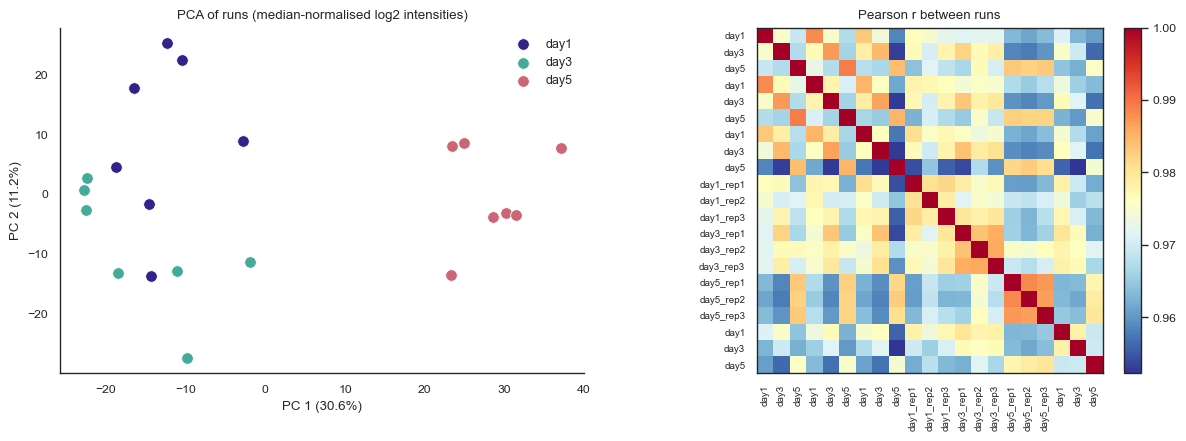

Within-day Pearson r: mean = 0.9795 [0.9697 - 0.9893]
Between-day Pearson r: mean = 0.9706 [0.9523 - 0.9884]


In [4]:
# PCA of runs
wide = agg.pivot_table(index='FullPeptideName', columns='run',
                       values='norm_log2', aggfunc='first')
wide_clean = wide.dropna()  # complete cases only

pca = PCA(n_components=2)
scores = pca.fit_transform(wide_clean.T.values)  # runs in rows
pca_df = pd.DataFrame(scores, columns=['PC1', 'PC2'], index=wide_clean.columns)
pca_df['day'] = pca_df.index.str.extract(r'_SW_(day\d)')[0].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# PCA scatter
ax = axes[0]
for d, c in DAY_COLORS.items():
    sub = pca_df[pca_df.day == d]
    ax.scatter(sub.PC1, sub.PC2, c=c, s=70, edgecolor='white',
              linewidth=0.6, label=d, zorder=3)
ax.set_xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of runs (median-normalised log2 intensities)')
ax.legend(frameon=False, fontsize=9)
sns.despine(ax=ax)

# Correlation heatmap
corr = wide_clean.corr()
day_labels = [r.split('_SW_')[1] for r in corr.columns]
ax = axes[1]
im = ax.imshow(corr.values, vmin=corr.values.min(), vmax=1.0, cmap='RdYlBu_r')
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(day_labels, rotation=90, fontsize=7)
ax.set_yticklabels(day_labels, fontsize=7)
ax.set_title('Pearson r between runs')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
for ext in ('pdf', 'png'):
    out = os.path.join(figure_path, 'pdf' if ext == 'pdf' else '.',
                       f'global_day_similarity.{ext}')
    os.makedirs(os.path.dirname(out), exist_ok=True)
    fig.savefig(out, dpi=figure_dpi, bbox_inches='tight')
plt.show()

within  = [corr.loc[r1, r2]
           for i, r1 in enumerate(corr.index)
           for r2 in corr.index[i+1:]
           if r1.split('_SW_')[1] == r2.split('_SW_')[1]]
between = [corr.loc[r1, r2]
           for i, r1 in enumerate(corr.index)
           for r2 in corr.index[i+1:]
           if r1.split('_SW_')[1] != r2.split('_SW_')[1]]
print(f'Within-day Pearson r: mean = {np.mean(within):.4f} '
      f'[{np.min(within):.4f} - {np.max(within):.4f}]')
print(f'Between-day Pearson r: mean = {np.mean(between):.4f} '
      f'[{np.min(between):.4f} - {np.max(between):.4f}]')

### Reading the Global Similarity Plots

The PCA and correlation heatmap tell a consistent story: acquisition day is visible, but it is not dominant enough to fragment the dataset into sharply separated run clusters. Day 5 tends to shift furthest along the first principal component, while days 1 and 3 remain closer and partially overlapping. That pattern indicates directional day structure rather than wholesale batch replacement.

The correlation summary supports the same interpretation. Mean within-day correlation is **0.9795**, compared with **0.9706** between days. The gap is real, so day contributes systematic structure, but the absolute correlation levels remain very high across all comparisons. In practical terms, the benchmark already contains measurable day-associated background variation before any synthetic perturbation is introduced, yet the baseline signal is still dominated by overall reproducibility.

## Part 2 — Peptide-Level Variation Across Days

For each peptide we compute:
- the **coefficient of variation (CV)** of log₂ intensities across runs, separately within each day and across all runs;
- a **1-way ANOVA** (factor = day) to flag peptides with a statistically significant day effect.

In [5]:
# ── Peptide-level CVs and ANOVA ──────────────────────────────────────────────
# Within-day CV per peptide
pep_stats = (agg.groupby(['FullPeptideName', 'day'])['norm_log2']
             .agg(['mean', 'std']).reset_index())
pep_stats['cv'] = pep_stats['std'] / pep_stats['mean'].abs()  # CV on log2 scale

# Overall CV per peptide
pep_overall = (agg.groupby('FullPeptideName')['norm_log2']
               .agg(['mean', 'std']).reset_index())
pep_overall['cv_overall'] = pep_overall['std'] / pep_overall['mean'].abs()

# 1-way ANOVA per peptide (day as factor)
anova_results = []
for pep, grp in agg.groupby('FullPeptideName'):
    groups = [g['norm_log2'].values for _, g in grp.groupby('day')]
    if len(groups) == 3 and all(len(g) >= 2 for g in groups):
        F, p = sp_stats.f_oneway(*groups)
        anova_results.append({'peptide': pep, 'F': F, 'pval': p})

anova_df = pd.DataFrame(anova_results)
anova_df['pval_bh'] = sp_stats.false_discovery_control(anova_df['pval'], method='bh')
n_sig_005 = (anova_df['pval_bh'] < 0.05).sum()
n_sig_001 = (anova_df['pval_bh'] < 0.01).sum()

print(f'Peptides tested: {len(anova_df):,}')
print(f'Significant day effect (BH < 0.05): {n_sig_005:,}  '
      f'({n_sig_005/len(anova_df)*100:.1f}%)')
print(f'Significant day effect (BH < 0.01): {n_sig_001:,}  '
      f'({n_sig_001/len(anova_df)*100:.1f}%)')

Peptides tested: 22,247
Significant day effect (BH < 0.05): 16,346  (73.5%)
Significant day effect (BH < 0.01): 13,713  (61.6%)


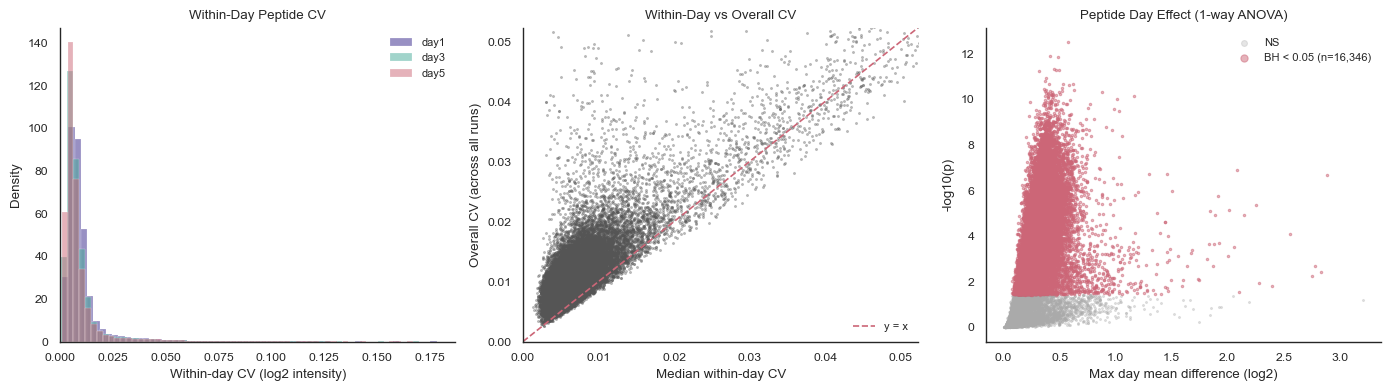

In [6]:
# Visualisation: CV distributions + volcano
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (A) Within-day CV distributions
ax = axes[0]
for d, c in DAY_COLORS.items():
    sub = pep_stats[pep_stats.day == d]['cv'].dropna()
    ax.hist(sub, bins=60, density=True, alpha=0.5, color=c, label=d, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Within-day CV (log2 intensity)')
ax.set_ylabel('Density')
ax.set_title('Within-Day Peptide CV')
ax.legend(frameon=False, fontsize=8)
ax.set_xlim(0, ax.get_xlim()[1])
sns.despine(ax=ax)

# (B) Overall CV vs within-day median CV
ax = axes[1]
med_within = pep_stats.groupby('FullPeptideName')['cv'].median().reset_index(name='cv_within_med')
merged = med_within.merge(pep_overall[['FullPeptideName', 'cv_overall']], on='FullPeptideName')
ax.scatter(merged['cv_within_med'], merged['cv_overall'], s=2, alpha=0.3, color='#555555')
lim = max(merged['cv_within_med'].quantile(0.99), merged['cv_overall'].quantile(0.99))
ax.plot([0, lim], [0, lim], '--', color='#CC6677', lw=1.2, label='y = x')
ax.set_xlabel('Median within-day CV')
ax.set_ylabel('Overall CV (across all runs)')
ax.set_title('Within-Day vs Overall CV')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend(fontsize=8, frameon=False)
sns.despine(ax=ax)

# (C) ANOVA volcano: effect size vs significance
ax = axes[2]
# Effect size = max day-mean difference (log2) across days
day_means = agg.groupby(['FullPeptideName', 'day'])['norm_log2'].mean().unstack()
anova_df = anova_df.set_index('peptide') if 'peptide' in anova_df.columns else anova_df
anova_df['max_diff'] = day_means.max(axis=1) - day_means.min(axis=1)
sig_mask = anova_df['pval_bh'] < 0.05
ax.scatter(anova_df.loc[~sig_mask, 'max_diff'],
           -np.log10(anova_df.loc[~sig_mask, 'pval']),
           s=2, alpha=0.3, color='#AAAAAA', label='NS')
ax.scatter(anova_df.loc[sig_mask, 'max_diff'],
           -np.log10(anova_df.loc[sig_mask, 'pval']),
           s=3, alpha=0.5, color='#CC6677', label=f'BH < 0.05 (n={sig_mask.sum():,})')
ax.set_xlabel('Max day mean difference (log2)')
ax.set_ylabel('-log10(p)')
ax.set_title('Peptide Day Effect (1-way ANOVA)')
ax.legend(fontsize=8, frameon=False, markerscale=3)
sns.despine(ax=ax)

fig.tight_layout()
for ext in ('pdf', 'png'):
    out = os.path.join(figure_path, 'pdf' if ext == 'pdf' else '.',
                       f'peptide_day_variation.{ext}')
    os.makedirs(os.path.dirname(out), exist_ok=True)
    fig.savefig(out, dpi=figure_dpi, bbox_inches='tight')
plt.show()

### Reading the Peptide-Level Results

The within-day CV distributions are concentrated near zero, showing that peptide intensities are generally stable within a single acquisition day after normalisation. In the middle panel, many points sit above the diagonal, meaning peptide variability increases when runs from different days are pooled together. That is the signature expected if day contributes a small but widespread source of variation.

The ANOVA panel adds an important nuance. A large fraction of peptides, **16,346 of 22,247** or **73.5%**, are significant at BH < 0.05, but most of those significant peptides cluster at relatively modest day-mean differences. This is a high-dimensional precision effect rather than evidence for pervasive large shifts. The main takeaway is that day effects are common enough to be statistically detectable across many peptides, while their magnitude is usually limited.

## Part 3 — Protein-Level Day Effects

Summarise at the protein level: median peptide log₂ intensity per (protein, run), then test for a day effect per protein.

In [7]:
# Protein-level day effects
prot_agg = (agg.groupby(['ProteinName', 'run', 'day'])['norm_log2']
            .median().reset_index(name='prot_log2'))

# 1-way ANOVA per protein
prot_anova = []
for prot, grp in prot_agg.groupby('ProteinName'):
    groups = [g['prot_log2'].values for _, g in grp.groupby('day')]
    if len(groups) == 3 and all(len(g) >= 2 for g in groups):
        F, p = sp_stats.f_oneway(*groups)
        means = {d: g['prot_log2'].mean() for d, g in grp.groupby('day')}
        max_diff = max(means.values()) - min(means.values())
        prot_anova.append({'protein': prot, 'F': F, 'pval': p, 'max_day_diff': max_diff})

prot_df = pd.DataFrame(prot_anova)
prot_df['pval_bh'] = sp_stats.false_discovery_control(prot_df['pval'], method='bh')

n_prot_sig = (prot_df['pval_bh'] < 0.05).sum()
n_prot_large = ((prot_df['pval_bh'] < 0.05) & (prot_df['max_day_diff'] > 1.0)).sum()
print(f'Proteins tested: {len(prot_df):,}')
print(f'Significant day effect (BH < 0.05): {n_prot_sig:,} '
      f'({n_prot_sig/len(prot_df)*100:.1f}%)')
print(f'  of which abs(log2 diff) > 1.0 (>2-fold): {n_prot_large:,}')

Proteins tested: 2,217
Significant day effect (BH < 0.05): 1,262 (56.9%)
  of which abs(log2 diff) > 1.0 (>2-fold): 1


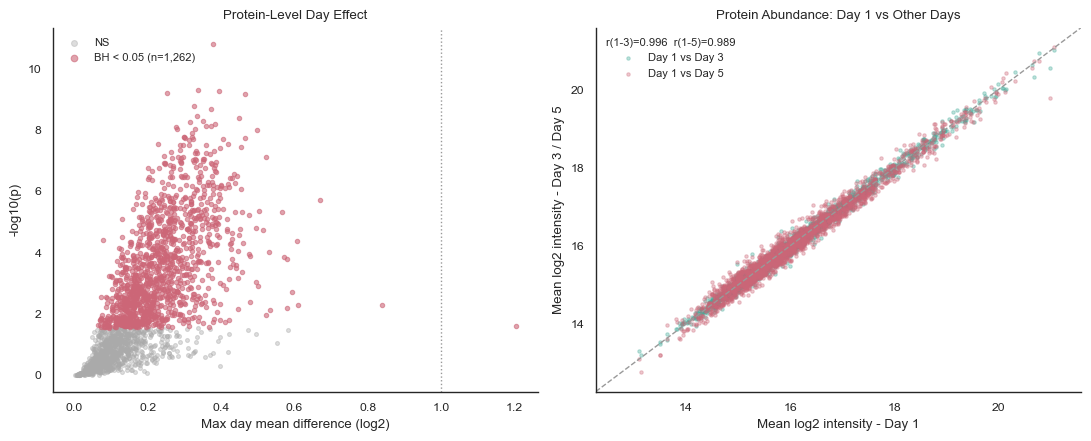

Pearson r - Day1-Day3: 0.9960   Day1-Day5: 0.9891


In [8]:
# Protein-level visualisation
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# (A) Volcano: protein day effect
ax = axes[0]
sig_mask_p = prot_df['pval_bh'] < 0.05
ax.scatter(prot_df.loc[~sig_mask_p, 'max_day_diff'],
           -np.log10(prot_df.loc[~sig_mask_p, 'pval']),
           s=8, alpha=0.4, color='#AAAAAA', label='NS')
ax.scatter(prot_df.loc[sig_mask_p, 'max_day_diff'],
           -np.log10(prot_df.loc[sig_mask_p, 'pval']),
           s=10, alpha=0.6, color='#CC6677', label=f'BH < 0.05 (n={sig_mask_p.sum():,})')
ax.axvline(1.0, ls=':', color='#999999', lw=1)
ax.set_xlabel('Max day mean difference (log2)')
ax.set_ylabel('-log10(p)')
ax.set_title('Protein-Level Day Effect')
ax.legend(fontsize=8, frameon=False, markerscale=1.5)
sns.despine(ax=ax)

# (B) Day-to-day scatter: median protein abundance Day1 vs Day3, Day1 vs Day5
prot_day_means = prot_agg.groupby(['ProteinName', 'day'])['prot_log2'].mean().unstack()
ax = axes[1]
ax.scatter(prot_day_means['day1'], prot_day_means['day3'],
           s=6, alpha=0.35, color=DAY_COLORS['day3'], label='Day 1 vs Day 3')
ax.scatter(prot_day_means['day1'], prot_day_means['day5'],
           s=6, alpha=0.35, color=DAY_COLORS['day5'], label='Day 1 vs Day 5')
lim = [prot_day_means.min().min() - 0.5, prot_day_means.max().max() + 0.5]
ax.plot(lim, lim, '--', color='#999999', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Mean log2 intensity - Day 1')
ax.set_ylabel('Mean log2 intensity - Day 3 / Day 5')
ax.set_title('Protein Abundance: Day 1 vs Other Days')

r13 = np.corrcoef(prot_day_means['day1'].dropna(), prot_day_means['day3'].dropna())[0, 1]
r15 = np.corrcoef(prot_day_means['day1'].dropna(), prot_day_means['day5'].dropna())[0, 1]
ax.legend(fontsize=8, frameon=False, title=f'r(1-3)={r13:.3f}  r(1-5)={r15:.3f}',
          title_fontsize=8)
sns.despine(ax=ax)

fig.tight_layout()
for ext in ('pdf', 'png'):
    out = os.path.join(figure_path, 'pdf' if ext == 'pdf' else '.',
                       f'protein_day_effects.{ext}')
    os.makedirs(os.path.dirname(out), exist_ok=True)
    fig.savefig(out, dpi=figure_dpi, bbox_inches='tight')
plt.show()

print(f'Pearson r - Day1-Day3: {r13:.4f}   Day1-Day5: {r15:.4f}')

### Reading the Protein-Level Results

Protein-level aggregation preserves the same overall pattern while making the scale of the day effect easier to judge. More than half of proteins, **1,262 of 2,217** or **56.9%**, are significant at BH < 0.05, so day-associated structure is not confined to a small subset of the proteome. However, the volcano plot shows that most significant proteins remain well below the vertical **log2 difference = 1** reference line.

That contrast is the key biological and technical insight from this section. Statistical significance is common, but large abundance shifts are rare: only **1 protein** exceeds both BH < 0.05 and an absolute day difference greater than 1.0. The day-to-day scatter reinforces this point, with extremely tight concordance between Day 1 and the later days (**r = 0.996** for Day 1 vs Day 3 and **r = 0.989** for Day 1 vs Day 5). The most defensible interpretation is broad low-amplitude technical drift rather than strong day-specific abundance remodelling.

In [9]:
# Summary table
summary = pd.DataFrame({
    'Metric': [
        'Proteins (>=4 peptides)',
        'Peptides (complete across days)',
        'Runs (7 per day x 3 days)',
        'Within-day Pearson r (mean)',
        'Between-day Pearson r (mean)',
        'Peptides with signif. day effect (BH<0.05)',
        'Proteins with signif. day effect (BH<0.05)',
        'Proteins with abs(log2 diff)>1.0 and BH<0.05',
    ],
    'Value': [
        f'{n_prots:,}',
        f'{n_peps:,}',
        f'{n_runs}',
        f'{np.mean(within):.4f}',
        f'{np.mean(between):.4f}',
        f'{n_sig_005:,} ({n_sig_005/len(anova_df)*100:.1f}%)',
        f'{n_prot_sig:,} ({n_prot_sig/len(prot_df)*100:.1f}%)',
        f'{n_prot_large:,}',
    ]
})

display(summary.style.hide(axis='index').set_caption(
    'Pre-modification day-to-day comparison summary'))

summary.to_csv(os.path.join(output_path, 'day_comparison_summary.csv'), index=False)
anova_df.to_csv(os.path.join(output_path, 'peptide_anova_day_effect.csv'))
prot_df.to_csv(os.path.join(output_path, 'protein_anova_day_effect.csv'), index=False)
print('Tables saved.')

Metric,Value
Proteins (>=4 peptides),"2,217"
Peptides (complete across days),"22,247"
Runs (7 per day x 3 days),21
Within-day Pearson r (mean),0.9795
Between-day Pearson r (mean),0.9706
Peptides with signif. day effect (BH<0.05),"16,346 (73.5%)"
Proteins with signif. day effect (BH<0.05),"1,262 (56.9%)"
Proteins with abs(log2 diff)>1.0 and BH<0.05,1


Tables saved.


### Benchmark Implication

The summary table condenses the central benchmark-design point of this notebook: before any synthetic perturbation is added, the dataset already contains reproducible but non-zero day structure at the run, peptide, and protein levels. The benchmark therefore starts from a realistic technical background rather than an idealized null. That is useful, because downstream methods are forced to operate in the presence of ordinary acquisition-day variation rather than on artificially clean data.

At the same time, this notebook also clarifies why the benchmark should not be treated as a neutral standalone arbiter of method calibration. In `Benchmark/01-DataProcessing.R`, the later in silico construction first introduces day-specific protein-level scaling and then applies peptide-subset reductions within selected proteins to generate perturbed benchmark profiles. That perturbation logic is structurally favorable to correlation- and grouping-oriented approaches such as COPF, because the synthetic signal is embedded inside coordinated protein-level profiles, while methods based on peptide-specific statistical contrasts, such as PeCorA and ProteoForge, must disentangle those engineered changes from the pre-existing day background and from the benchmark's own construction choices. For that reason, the benchmark is informative for comparative behavior, but it still needs to be interpreted alongside complete-control simulations that isolate calibration and power without inherited technical structure.

## Conclusion

The unmodified benchmark data show clear but mostly low-amplitude acquisition-day structure. Runs remain highly correlated overall, peptide reproducibility within day is strong, and many peptide- and protein-level day effects are statistically detectable even though large abundance shifts are rare. The most defensible interpretation is not that the benchmark is dominated by batch artifacts, but that it carries a broad technical background that later perturbation analyses must inherit.

That conclusion matters because the downstream benchmark is generated from `Benchmark/01-DataProcessing.R`, which does more than simply add isolated proteoform-like events. After the shared preprocessing steps reproduced here, the script introduces day-specific protein-level variation and then reduces Day 5 abundance for subsets of peptides within selected proteins. This creates a benchmark with structured synthetic signal superimposed on real day-to-day background. In practice, that design can advantage methods like COPF that capitalize on coordinated within-protein profile structure, while placing methods such as PeCorA and ProteoForge under a less favorable regime because they rely on peptide-level statistical comparisons against a background that is already technically patterned.

For that reason, this benchmark notebook should be read as a context-setting companion rather than as a complete validation story by itself. It explains what the unmodified substrate looks like, why benchmark positives are not injected into a clean null, and why the separate simulation analyses with true complete-control settings were necessary to evaluate calibration and power without the confounding influence of inherited benchmark structure.

In [10]:
print(f'Notebook completed in {time.time() - startTime:.0f}s')

Notebook completed in 31s
